# Proyecto 2: Fusión de Perspectivas - Registro de Imágenes y Medición del Mundo Real

En este trabajo pondremos en práctica los conceptos fundamentales del registro de imágenes (image registration) para crear una vista unificada a partir de múltiples perspectivas.

## 1. Configuración del entorno de trabajo

In [ ]:
!pip install opencv-python matplotlib numpy PIL pathlib

In [1]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from google.colab.patches import cv2_imshow
import pandas as pd
import glob
from math import sqrt
from skimage.metrics import normalized_mutual_information
from scipy.stats import pearsonr
import itertools
from tqdm import tqdm


In [13]:
#Asigna las rutas: 1. Cargar las imágenes 2. Guardar los resultados
project_dir = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/proyecto-registro-imagenes"
results_dir= os.path.join(project_dir, "results", "01_Imagenes_Sinteticas")

#Carpeta para el dataset
ruta_guardado_dataset = os.path.join(results_dir, "dataset_transformaciones")
os.makedirs(ruta_guardado_dataset, exist_ok=True)

## 2. Validación con Imágenes Sintéticas


### 2.1 Creación del conjunto de imágenes sintéticas con transformaciones conocidas (rotación,traslación, escala)

In [6]:
# Función para generar imágenes sintéticas

def create_sample_image(
    width=400, height=300, # Permite cambiar el tamaño de la imagen
):
    """
    Genera una imagen sintética con diferentes formas geométricas. 3 rentángulos y dos círculos
    width, height : tamaño de la imagen

    Retorna:
        img : imagen sintética RGB (uint8)
    """

    # Imagen en negro
    img = np.zeros((height, width, 3), dtype=np.uint8)

    # Gradiente de fondo (canal rojo)
    for i in range(height):
      img[i, :, 0] = int(255 * i / height)

    #Posiciones relativas para los objetos

    rects = [
        (0.05, 0.05, 0.25, 0.2),   # arriba izquierda
        (0.55, 0.1, 0.3, 0.18),    # arriba derecha
        (0.1,  0.65, 0.3, 0.25)    # abajo izquierda
    ]

    circles = [
        (0.4, 0.45, 0.12),  # centro
        (0.7, 0.75, 0.12)   # abajo derecha
    ]

    #Se dibujan los rectángulos ajustando las posiciones al tamaño de la imagen
    for (x_rel, y_rel, w_rel, h_rel) in rects:
        x1 = int(x_rel * width)
        y1 = int(y_rel * height)
        x2 = int(x1 + w_rel * width)
        y2 = int(y1 + h_rel * height)
        color = tuple(np.random.randint(0, 256, size=3).tolist()) #Asigna colores aleatorios
        cv2.rectangle(img, (x1, y1), (x2, y2), color, -1)         #Agrega el elemento a la imagen

     #Se dibujan los rectángulos ajustando las posiciones al tamaño de la imagen
    for (cx_rel, cy_rel, r_rel) in circles:
        cx = int(cx_rel * width)
        cy = int(cy_rel * height)
        r = int(r_rel * min(width, height))  # radio proporcional al menor lado
        color = tuple(np.random.randint(0, 256, size=3).tolist())
        cv2.circle(img, (cx, cy), r, color, -1)

   # Agregar ruido aleatorio
    noise = np.random.randint(0, 50, img.shape, dtype=np.uint8)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img


#Función de transformaciones
def transformaciones(img, angle=0, tx=0, ty=0, scale=1.0):
    """
    Aplica transformaciones sobre la imagen:
    - angle (°): rotación
    - tx, ty (px): traslación
    - scale: factor de escala
    """
    h, w = img.shape[:2]        #Toma las dimensiones de la imagen
    center = (w // 2, h // 2)   #Se define el centro de rotación en la mitad de la imagen
    rot = cv2.getRotationMatrix2D(center, angle, scale) #crea la matriz rot para rotar y escalar
    rot[:, 2] += [tx, ty]                                 #Suma a la matriz de transformación la traslación
    transformed = cv2.warpAffine(img, rot, (w, h))        #Aplica la transformación a la img
    return transformed, rot                               #Devuelve la matriz de transformación y la imagen transformada



In [9]:
#Se generan todas las imágenes transformadas y se guardan

def generate_dataset(
    img_base,      #imagen de entrada
    output_dir="dataset_transformaciones",  #directorio de Salida
    rotation_angles=[10, 20, 30],           #Define angulos de rot
    translations=[(20, 0), (0, 20), (30, -15)], #Se definen traslaciones
    scales=[0.8, 1.2, 1.5]                      #Se definen escalas
):
    os.makedirs(output_dir, exist_ok=True) #Se crea el directorio para guardar las imágenes

    #Genera y guarda las rotaciones
    for angle in rotation_angles:
        img_t, M = transformaciones(img_base, angle=angle)
        cv2.imwrite(f"{output_dir}/rot_{angle}deg.png", img_t)
        np.savetxt(f"{output_dir}/rot_{angle}deg_matrix.txt", M, fmt="%.6f")

    #Genera y guarda las traslaciones
    for tx, ty in translations:
        img_t, M = transformaciones(img_base, tx=tx, ty=ty)
        cv2.imwrite(f"{output_dir}/trans_{tx}_{ty}.png", img_t)
        np.savetxt(f"{output_dir}/trans_{tx}_{ty}_matrix.txt", M, fmt="%.6f")


    #Genera y guarda el cambio de escala
    for s in scales:
        img_t, M = transformaciones(img_base, scale=s)
        cv2.imwrite(f"{output_dir}/scale_{s:.2f}.png", img_t)
        np.savetxt(f"{output_dir}/scale_{s:.2f}_matrix.txt", M, fmt="%.6f")

    print(f"Dataset generado en: {os.path.abspath(output_dir)}")

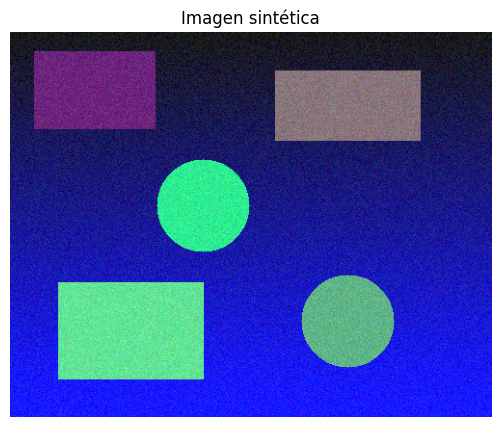

In [8]:
#Se muestra y se guarda la imagen generada

ruta_guardado = os.path.join(results_dir, "imagen_sintetica.png")
img = create_sample_image(width=500,height=400)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen sintética")
plt.axis('off')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#Se aplican las transformaciones y se genera el dataset
generate_dataset(img,ruta_guardado_dataset, rotation_angles=[20],translations=[(30, -15)], scales=[0.8] )

Dataset generado en: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/proyecto-registro-imagenes/results/01_Imagenes_Sinteticas/dataset_transformaciones


### 2.2 Algoritmo de registro

In [15]:
#Se define el algoritmo de registro

def algoritmo_registro(
    img,                    #Imagen Origina
    img_moving_path,        #Ruta a las imágenes transformadas
    results_dir,            #Ruta al directoro de salida
    sift_param=[1000,0.04,10,1.6], #Parámetros para SIFT
    flann_param=[5,50,0.7], #Paárametros FLANN Ratio : trees, checks, ratio threshold
    ransac_param=[3.0,0.99,2000],      #Threshold para RAMSAC, confidence, maxIters
    mostrar_inliers=True,
    mostrar_comp=True,

):

    #Se leen las imágenes
    #img_fixed = cv2.imread(img_fixed_path)
    img_moving = cv2.imread(img_moving_path)

    #Se crea la ruta de guardado
    nombre = os.path.splitext(os.path.basename(img_moving_path))[0]


    #1. Preprocesamiento
    # ---- Cargar las imágenes y las convierte a gray ----
    moving_gray = cv2.cvtColor(img_moving, cv2.COLOR_BGR2GRAY)
    fixed_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #Ecualización del histograma
    #fixed_gray = cv2.equalizeHist(fixed_gray)
    #moving_gray = cv2.equalizeHist(moving_gray)

    #Eliminación de ruido
    fixed_gray = cv2.GaussianBlur(fixed_gray, (3, 3), 0)
    moving_gray = cv2.GaussianBlur(moving_gray, (3, 3), 0)


    #print(fixed_gray.shape)
    #print(img_moving.shape)

    #2. Detección de puntos en común: SIFT ----
    # Detectar características distintivas

    sift = cv2.SIFT_create(
    nfeatures=sift_param[0],
    contrastThreshold=sift_param[1],
    edgeThreshold=sift_param[2],
    sigma=sift_param[3]
    )

    kp1, des1 = sift.detectAndCompute(fixed_gray, None)
    kp2, des2 = sift.detectAndCompute(moving_gray, None)
    if des2 is None or len(kp2) < 3:
        print(f"Pocos puntos en la imagen")

    print(f"Puntos detectados en imagen Original: {len(kp1)}")
    print(f"Puntos detectados en imagen transformada: {len(kp2)}")

    #3. Emparejamiento
    #Encontrar puntos correspondientes

    FLANN_INDEX_KDTREE = 1                                      #Se incia FLANN
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=flann_param[0])  #Se ajustan los parámetros
    search_params = dict(checks=flann_param[1])                             #Se ajustan los parámetros de busqueda
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # ---- Matching con ratio test ----
    matches = flann.knnMatch(des1, des2, k=2)
    good_matches = [m for m, n in matches if m.distance < flann_param[2] * n.distance]  #Se determina el ratio y se evalua
    if len(good_matches) < 3:
        print(f"Muy pocos matches en la imagen")


    print(f"Matches buenos después del ratio test: {len(good_matches)}")

    # ---- Extraer coordenadas de los puntos comunes ----
    pts_fixed = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1,1,2)
    pts_moving = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1,1,2)

    # ---- Estimar transformación con RANSAC ----
    M_est, inliers = cv2.estimateAffinePartial2D(
        pts_moving,
        pts_fixed,
        method=cv2.RANSAC,
        ransacReprojThreshold=ransac_param[0],
        confidence=ransac_param[1],
        maxIters=ransac_param[2],
    )
    if M_est is None:
        print(f"No se estimó M para la imagen")


    inlier_count = int(np.sum(inliers))


    # --- Visualizar inliers---
    # Filtrar y limitar inliers
    inlier_matches = [m for m, ok in zip(good_matches, inliers.ravel()) if ok]

    # Dibujar matches
    img_inliers = cv2.drawMatches(
        img, kp1,
        img_moving, kp2,
        inlier_matches,
        None,
        matchColor=(0,255,0),
        singlePointColor=(255,0,0),
        flags=(cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    )

    # Mostrar la figura
    if mostrar_inliers is True:
        fig=plt.figure(figsize=(14, 4))
        plt.imshow(cv2.cvtColor(img_inliers, cv2.COLOR_BGR2RGB))
        plt.title(f"Inliers Finales RANSAC ({len(inlier_matches)})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        ruta_guardado = os.path.join(results_dir, f"{nombre}_inliner_matches.png")
        fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
        plt.close()



    #4. Estimación de transformación
    #Encontrar la matriz que mapea móvil → fija
    h, w = fixed_gray.shape
    aligned = cv2.warpAffine(img_moving, M_est, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)


    #Muestra el resultado de las imágenes

    if mostrar_comp is True:
        fig=plt.figure(figsize=(20,10))
        plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(cv2.cvtColor(img_moving, cv2.COLOR_BGR2RGB)); plt.title('Transformada'); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)); plt.title('Registrada'); plt.axis('off')
        plt.show()

        ruta_guardado = os.path.join(results_dir, f"{nombre}_comparacion.png")
        fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
        plt.close()


    return fixed_gray,aligned, M_est, inliers, kp1, kp2, good_matches

### 2.3 Comparación de las transformaciones estimadas con las verdaderas (ground truth) y Métricas de error (RMSE, error angular, etc.)

In [16]:
# Se define la función para comparar la transformación estimada con la Verdadera y las métricas de error

def decompose_matrix(M):
    """Descompone matriz afín en ángulo (°), escala y traslaciones."""
    theta = np.degrees(np.arctan2(M[1,0], M[0,0]))
    scale = np.sqrt(M[0,0]**2 + M[0,1]**2)
    tx = M[0,2]
    ty = M[1,2]
    return theta, scale, tx, ty

def angle_diff(a, b):
    """Diferencia angular mínima en grados."""
    return abs(((a - b + 180) % 360) - 180)

def calcular_RMSE(img1, img2):
    """Error cuadrático medio por píxel."""
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    return np.sqrt(np.mean(diff**2))

def calcular_NCC(img1, img2):
    """Correlación cruzada normalizada (NCC)."""
    img1_f = img1.astype(np.float32).ravel()
    img2_f = img2.astype(np.float32).ravel()
    corr, _ = pearsonr(img1_f, img2_f)
    return corr

def calcular_MI(img1, img2):
    """Información mutua normalizada (MI)."""
    return normalized_mutual_information(img1, img2)

def comparar_transformaciones(img_fixed, img_registrada, M_est, M_gt):
    """Compara dos matrices de transformación, recibe ambas matrices y devuelve el error"""

    img_registrada = cv2.cvtColor(img_registrada, cv2.COLOR_BGR2GRAY)


    # Invertir M_gt (porque transforma base → transformada)
    M_gt_inv = cv2.invertAffineTransform(M_gt)

    # Descomponer matrices
    theta_gt, scale_gt, tx_gt, ty_gt = decompose_matrix(M_gt_inv)
    theta_est, scale_est, tx_est, ty_est = decompose_matrix(M_est)

    # Calcular diferencias
    error_ang = angle_diff(theta_gt, theta_est)
    error_scale = abs(scale_gt - scale_est)
    error_tx = abs(tx_gt - tx_est)
    error_ty = abs(ty_gt - ty_est)

    # --- RMSE ---
    rmse = calcular_RMSE(img_fixed, img_registrada)

    # --- NCC ---
    ncc = calcular_NCC(img_fixed, img_registrada)

    # --- MI ---
    mi = calcular_MI(img_fixed, img_registrada)


    resultados= {

    "error_angular": {"valor": error_ang, "texto": f"{error_ang:.3f}°"},
    "error_escala":  {"valor": (error_scale * 100), "texto": f"{error_scale*100:.3f}%"},
    "error_tx":      {"valor": error_tx, "texto": f"{error_tx:.3f}px"},
    "error_ty":      {"valor": error_ty, "texto": f"{error_ty:.3f}px"},
    "RMSE":          {"valor": rmse, "texto": f"{rmse:.3f}"},
    "NCC":           {"valor": ncc, "texto": f"{ncc:.3f}"},
    "MI":            {"valor": mi, "texto": f"{mi:.3f}"}
    }

    return resultados

### Se aplica el algoritmo de registro y las métricas

In [17]:
#Se crea el buble que recorre todas las imagenes en el dataset
for img_path in sorted(glob.glob(os.path.join(ruta_guardado_dataset, "*.png"))):
    if "matrix" in img_path:
        continue

    nombre = os.path.basename(img_path)
    #print(nombre)
    matrix_gt_path = img_path.replace(".png", "_matrix.txt")

    M_gt = np.loadtxt(matrix_gt_path)
    #M_gt_inv = cv2.invertAffineTransform(M_gt)

    print("=====================\n")
    # Estimar matriz
    fixed_gray,img_registrada, M_est, inliers, kp1, kp2, good_matches=algoritmo_registro(
        img,
        img_path,
        results_dir,
        mostrar_inliers=True,
        mostrar_comp=True,
    )

    errores = comparar_transformaciones(fixed_gray,img_registrada,M_est, M_gt)

    print("=== RESULTADOS DE COMPARACIÓN ===")
    for nombre, datos in errores.items():
      print(f"{nombre:15s}: {datos['texto']}")





Output hidden; open in https://colab.research.google.com to view.

### 2.4 Variación de parámetros

In [18]:
#Se Crea la comparación de parámetros con la imagen base de la traslación
#Se deben cambiar las ubicaciones de la imagen y la matriz
M_gt = np.loadtxt("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/proyecto-registro-imagenes/results/01_Imagenes_Sinteticas/dataset_transformaciones/trans_30_-15_matrix.txt")


#Se definen los parámetros a probar
param_grid = {
    "nfeatures": [500, 1000],
    "contrastThreshold": [0.02, 0.04],
    "edgeThreshold": [5, 10],
    "trees": [4, 6],
    "checks": [50, 100],
    "ratio": [0.6, 0.7],
    "ransacReprojThreshold": [1.0, 2.0]
}

# Crear combinaciones
param_combinations = list(itertools.product(
    param_grid["nfeatures"],
    param_grid["contrastThreshold"],
    param_grid["edgeThreshold"],
    param_grid["trees"],
    param_grid["checks"],
    param_grid["ratio"],
    param_grid["ransacReprojThreshold"]
))

resultados = []

#Se crea un buble con las diferentes combinaciones para evaluar
for (nfeat, cth, eth, trees, checks, ratio, rth) in tqdm(param_combinations):

    sift_param = [nfeat, cth, eth, 1.6]
    flann_param = [trees, checks, ratio]
    ransac_param = [rth, 0.99, 2000]

    fixed_gray, img_registrada, M_est, inliers, kp1, kp2, good_matches = algoritmo_registro(
        img,
        "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/proyecto-registro-imagenes/results/01_Imagenes_Sinteticas/dataset_transformaciones/trans_30_-15.png",
        results_dir,
        sift_param,
        flann_param,
        ransac_param,
        mostrar_inliers=False,
        mostrar_comp=False,
    )

    # Evaluar métricas si se encontró una matriz válida
    if M_est is not None:
        metricas = comparar_transformaciones(fixed_gray, img_registrada, M_est, M_gt)

        resultados.append({
            "nfeatures": nfeat,
            "contrastThreshold": cth,
            "edgeThreshold": eth,
            "trees": trees,
            "checks": checks,
            "ratio": ratio,
            "ransacReprojThreshold": rth,
            "inliers": int(np.sum(inliers)) if inliers is not None else 0,
            "RMSE": metricas["RMSE"]["valor"],
            "NCC": metricas["NCC"]["valor"],
            "MI": metricas["MI"]["valor"],
            "error_angular": metricas["error_angular"]["valor"],
            "error_tx": metricas["error_tx"]["valor"],
            "error_ty": metricas["error_ty"]["valor"],
            "error_escala": metricas["error_escala"]["valor"]
        })
    else:
        resultados.append({
            "nfeatures": nfeat,
            "contrastThreshold": cth,
            "edgeThreshold": eth,
            "trees": trees,
            "checks": checks,
            "ratio": ratio,
            "ransacReprojThreshold": rth,
            "inliers": 0,
            "RMSE": None,
            "NCC": None,
            "MI": None,
            "error_angular": None,
            "error_tx": None,
            "error_ty": None,
            "error_escala": None
        })


# Guardar resultados
ruta_guardado_param = os.path.join(results_dir, "variacion_parametros.csv")
df = pd.DataFrame(resultados)
df.to_csv(ruta_guardado_param, index=False)
print("Resultados guardados en 'variacion_parametros.csv'")
df.head()


  2%|▏         | 2/128 [00:00<00:13,  9.08it/s]

Puntos detectados en imagen Original: 223
Puntos detectados en imagen transformada: 283
Matches buenos después del ratio test: 185
Puntos detectados en imagen Original: 223
Puntos detectados en imagen transformada: 283
Matches buenos después del ratio test: 185


  3%|▎         | 4/128 [00:00<00:13,  9.12it/s]

Puntos detectados en imagen Original: 223
Puntos detectados en imagen transformada: 283
Matches buenos después del ratio test: 191
Puntos detectados en imagen Original: 223
Puntos detectados en imagen transformada: 283
Matches buenos después del ratio test: 191


  5%|▍         | 6/128 [00:00<00:13,  9.02it/s]

...

 98%|█████████▊| 126/128 [00:15<00:00,  5.71it/s]

Puntos detectados en imagen Original: 168
Puntos detectados en imagen transformada: 183
Matches buenos después del ratio test: 153
Puntos detectados en imagen Original: 168
Puntos detectados en imagen transformada: 183
Matches buenos después del ratio test: 153


100%|██████████| 128/128 [00:15<00:00,  8.12it/s]

Puntos detectados en imagen Original: 168
Puntos detectados en imagen transformada: 183
Matches buenos después del ratio test: 156
Puntos detectados en imagen Original: 168
Puntos detectados en imagen transformada: 183
Matches buenos después del ratio test: 156
Resultados guardados en 'variacion_parametros.csv'


,nfeatures,contrastThreshold,edgeThreshold,trees,checks,ratio,ransacReprojThreshold,inliers,RMSE,NCC,MI,error_angular,error_tx,error_ty,error_escala
0,500,0.02,5,4,50,0.6,1.0,180,8.889062,0.984118,1.178581,0.000008,0.000450,0.000364,0.000043
1,500,0.02,5,4,50,0.6,2.0,182,8.601290,0.985100,1.182460,0.003371,0.007232,0.009611,0.006953
2,500,0.02,5,4,50,0.7,1.0,184,8.889062,0.984118,1.178581,0.000509,0.002768,0.002093,0.000192
3,500,0.02,5,4,50,0.7,2.0,187,8.439892,0.985640,1.184979,0.005403,0.008453,0.015405,0.010011
4,500,0.02,5,4,100,0.6,1.0,180,8.889062,0.984118,1.178581,0.000008,0.000450,0.000364,0.000043
